# Stage 1 — 50Salads dataset analysis

Goal: understand *why* 50Salads is hard for transcript-only temporal alignment,
using only the benchmark bundle (`groundTruth/` + `mapping.txt` + I3D `features/`).
No raw video (the official host is down).

Everything here uses `delta.data.stats`, `delta.align`, `delta.viz`.

In [1]:
import os
from pathlib import Path

# run from the repo root regardless of where the notebook is launched
_p = Path.cwd()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
os.chdir(_p)
print("cwd:", os.getcwd())

cwd: /Users/elizpayasli/Documents/GitHub/DELTA


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from delta.data import ActionSegDataset
from delta.data import stats
from delta.align import segmentation_report, segments
from delta.viz import plot_segmentation

pd.set_option("display.max_rows", 60)
ds = ActionSegDataset("50salads", "data/50salads")
FPS = stats.label_fps(ds)
NAMES = ds.action_names()
ds, FPS, len(NAMES)

(ActionSegDataset(name='50salads', root='data/50salads', n_videos=50, n_classes=19),
 30.0,
 19)

## 1. Basic facts

In [3]:
vdf = stats.video_df(ds)
print(f"{len(vdf)} videos, {len(NAMES)} classes, {FPS:.0f} fps")
print(f"split1 train/test: {len(ds.split(1,'train'))}/{len(ds.split(1,'test'))}")
vdf.describe().loc[["mean", "min", "max"]].T

50 videos, 19 classes, 30 fps
split1 train/test: 40/10


,mean,min,max
n_frames,11551.900000,7555.000000,18143.000000
dur_sec,385.063333,251.833333,604.766667
n_segments,19.980000,15.000000,26.000000
transcript_len,19.980000,15.000000,26.000000
n_unique_classes,18.320000,13.000000,19.000000
bg_frac,0.143897,0.061957,0.373920


~50 videos, ~20 action segments each, ~6.4 min long, ~30 fps → **long sequences
with many fine-grained transitions**. `action_start`/`action_end` wrap every
video (~14% of frames).

## 2. Class frequency — is it long-tailed?

In [4]:
fc = stats.frame_counts(ds)
sc = stats.segment_counts(ds)
freq = pd.DataFrame({
    "class": [NAMES[i] for i in range(len(NAMES))],
    "frames": [fc.get(i, 0) for i in range(len(NAMES))],
    "segments": [sc.get(i, 0) for i in range(len(NAMES))],
})
freq["frame_share_%"] = 100 * freq["frames"] / freq["frames"].sum()
freq = freq.sort_values("frames", ascending=False).reset_index(drop=True)
freq

,class,frames,segments,frame_share_%
0,peel_cucumber,61567,50,10.659199
1,cut_tomato,61363,59,10.623880
2,action_end,51344,50,8.889274
3,cut_cucumber,48413,57,8.381825
4,cut_cheese,47458,51,8.216484
5,cut_lettuce,47137,58,8.160909
6,serve_salad_onto_plate,34149,49,5.912274
7,action_start,30001,50,5.194124
8,add_oil,27383,51,4.740865
9,mix_ingredients,24853,61,4.302842


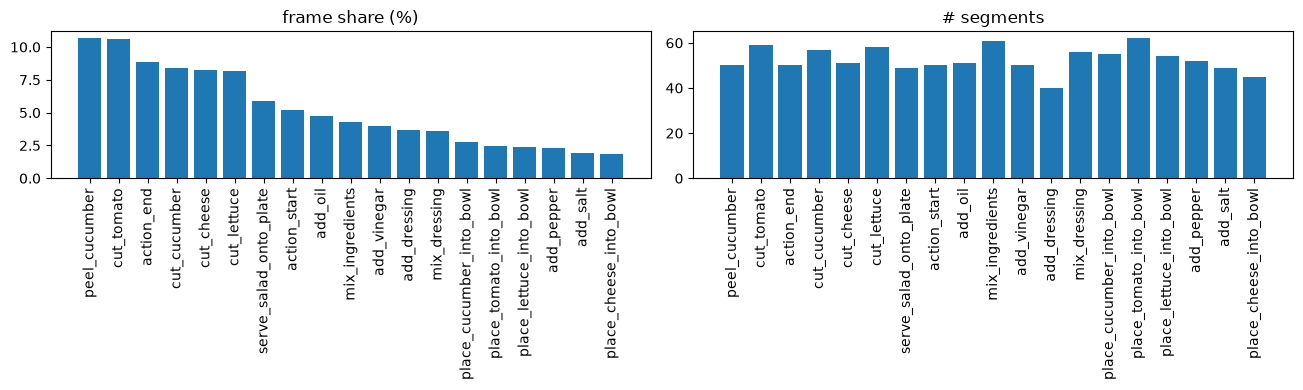

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(freq["class"], freq["frame_share_%"]); ax[0].set_title("frame share (%)")
ax[0].tick_params(axis="x", rotation=90)
ax[1].bar(freq["class"], freq["segments"]); ax[1].set_title("# segments")
ax[1].tick_params(axis="x", rotation=90)
fig.tight_layout()

The `cut_* / place_*_into_bowl` families and `mix_*` dominate frame count, while
the `add_{salt,vinegar,oil,pepper}` actions are short and rare in frames but
each appears once per recipe. A **frame-weighted** loss (what fully-supervised
methods optimise) is dominated by the long actions; a **transcript**-weighted
view counts every action once — the paper's "frequency bias vs procedural
structure" point. → **MoC (per-class), not MoF, is the headline metric.**

## 3. Segment-duration variability per class

Coefficient of variation (`cv = std/mean`): the most variable classes sit at
**cv ≈ 0.5–0.8** (e.g. `place_tomato_into_bowl`: mean ~8 s, cv 0.78 → lengths
roughly 2–20 s). A single ordered transcript occurrence tells you little about
extent ⇒ the duration head has weak signal (paper: duration loss = **+0.2 MoC
on 50S** vs +3.3 on Breakfast).

In [6]:
cdf = stats.class_duration_df(ds).sort_values("cv", ascending=False).reset_index(drop=True)
cdf.round(2)

,class_idx,class_name,n_instances,mean_sec,std_sec,cv,min_sec,max_sec
0,18,action_end,50,34.23,26.95,0.79,7.23,138.27
1,1,place_tomato_into_bowl,62,7.68,5.98,0.78,1.47,41.73
2,13,place_cucumber_into_bowl,55,9.56,6.01,0.63,0.33,31.47
3,14,add_dressing,40,17.69,10.42,0.59,5.60,61.73
4,12,cut_cucumber,57,28.31,16.35,0.58,2.87,83.93
5,10,mix_dressing,56,12.37,7.01,0.57,2.07,37.27
6,3,place_cheese_into_bowl,45,7.77,4.25,0.55,1.17,21.27
7,5,place_lettuce_into_bowl,54,8.44,4.58,0.54,1.70,27.80
8,15,mix_ingredients,61,13.58,7.01,0.52,0.17,43.10
9,4,cut_lettuce,58,27.09,13.89,0.51,0.67,67.10


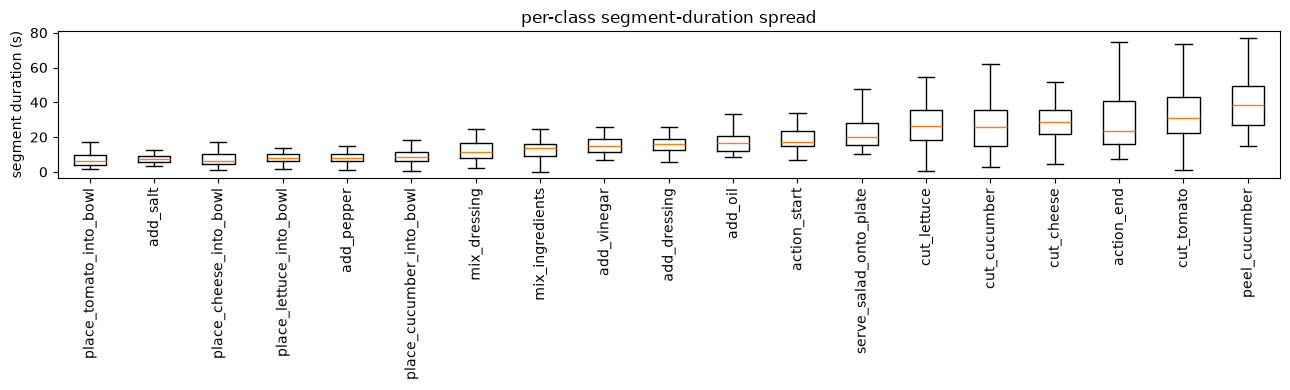

In [7]:
sdf = stats.segment_df(ds)
order = cdf.sort_values("mean_sec")["class_name"].tolist()
fig, ax = plt.subplots(figsize=(13, 4))
data = [sdf.loc[sdf["class_name"] == c, "dur_sec"].values for c in order]
ax.boxplot(data, showfliers=False)
ax.set_xticks(range(1, len(order) + 1)); ax.set_xticklabels(order, rotation=90)
ax.set_ylabel("segment duration (s)")
ax.set_title("per-class segment-duration spread"); fig.tight_layout()

## 4. How much does transcript *order* pin down the next action?

`transition_matrix[c]` = P(next action | current = c) over all transcripts.
Per-row entropy: 0 = deterministic successor, higher = ambiguous order.

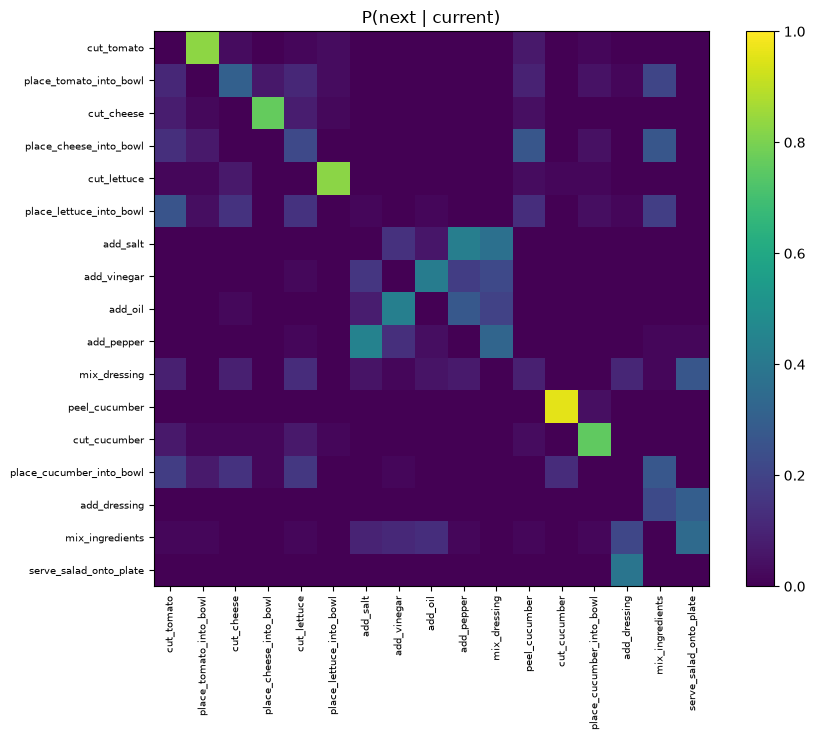

In [8]:
P = stats.transition_matrix(ds, normalize=True)
ent = stats.transition_entropy(ds)
real = [i for i in range(len(NAMES)) if NAMES[i] not in ("action_start", "action_end")]

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(P[np.ix_(real, real)], cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(real))); ax.set_xticklabels([NAMES[i] for i in real], rotation=90, fontsize=7)
ax.set_yticks(range(len(real))); ax.set_yticklabels([NAMES[i] for i in real], fontsize=7)
ax.set_title("P(next | current)"); fig.colorbar(im, fraction=0.046); fig.tight_layout()

In [9]:
mean_ent = np.nanmean([ent[i] for i in real])
print(f"mean next-action entropy over real classes: {mean_ent:.2f} bits "
      f"(~{2**mean_ent:.1f} effective successors)")
pd.Series({NAMES[i]: ent[i] for i in real}).sort_values(ascending=False).round(2)

mean next-action entropy over real classes: 1.85 bits (~3.6 effective successors)


mix_dressing                3.20
place_lettuce_into_bowl     2.83
place_tomato_into_bowl      2.75
mix_ingredients             2.66
place_cucumber_into_bowl    2.65
place_cheese_into_bowl      2.35
add_vinegar                 1.99
add_pepper                  1.95
add_oil                     1.90
add_salt                    1.70
add_dressing                1.52
cut_cucumber                1.42
cut_cheese                  1.28
cut_lettuce                 1.06
cut_tomato                  1.02
serve_salad_onto_plate      0.96
peel_cucumber               0.24
dtype: float64

~1.9 bits ⇒ each action has ~3-4 plausible successors. **The transcript order
alone does not disambiguate the timeline** — the visual transition score `V^a`
has to do real work, and on 50Salads the classes it must separate
(`cut_tomato`/`cut_cheese`/`cut_lettuce`/`cut_cucumber`,
`add_oil`/`add_vinegar`/`add_salt`/`add_pepper`) look nearly identical from a
fixed overhead camera.

## 5. Do the I3D features even show the boundaries?

ATBA's candidate boundaries come from a *class-agnostic* score built on frame
feature change. Proxy: cosine distance between consecutive I3D frames, overlaid
on the ground-truth boundaries. If boundaries don't stand out here, the
candidate set will miss true transitions no matter how good `V^a` is.

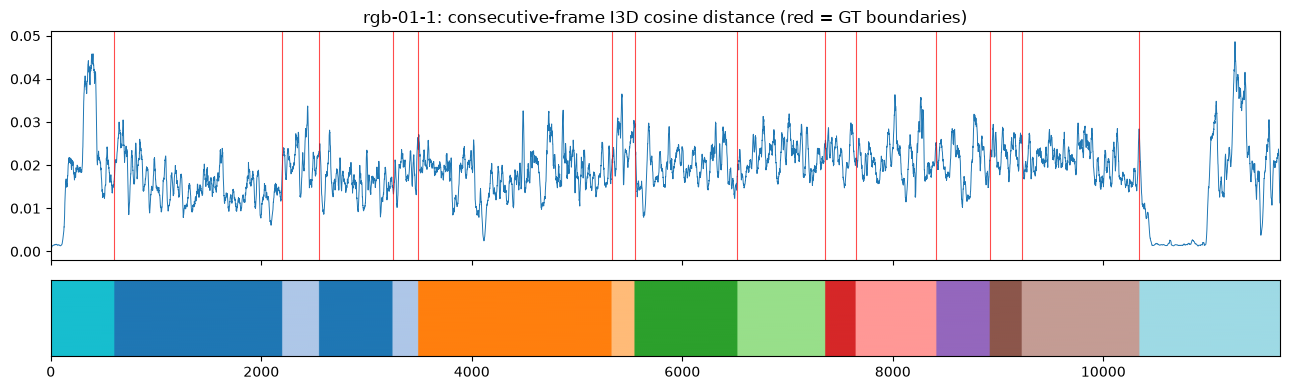

In [10]:
def boundary_proxy(vid, smooth=15):
    f = np.load(f"data/50salads/features/{vid}.npy").astype(np.float32)  # (D,T)
    f = f / (np.linalg.norm(f, axis=0, keepdims=True) + 1e-8)
    d = 1.0 - (f[:, 1:] * f[:, :-1]).sum(0)                              # (T-1,)
    k = np.ones(smooth) / smooth
    d = np.convolve(d, k, mode="same")
    y = ds.record(vid).frame_labels
    bnds = [s for _, s, _ in segments(y)][1:]
    return d, bnds, y

vid = ds.split(1, "test")[0]
d, bnds, y = boundary_proxy(vid)
fig, ax = plt.subplots(2, 1, figsize=(13, 4), sharex=True, height_ratios=[3, 1])
ax[0].plot(d, lw=0.7); [ax[0].axvline(b, color="r", lw=0.8, alpha=0.7) for b in bnds]
ax[0].set_title(f"{vid}: consecutive-frame I3D cosine distance (red = GT boundaries)")
ax[1].imshow(y[None, :], aspect="auto", cmap="tab20"); ax[1].set_yticks([])
fig.tight_layout()

In [11]:
# quantify: is the proxy higher at GT boundaries than at random frames?
rng = np.random.default_rng(0)
at_b, at_r = [], []
for vid in ds.split(1, "test"):
    d, bnds, y = boundary_proxy(vid)
    bnds = [b for b in bnds if 0 < b < len(d)]
    at_b += [d[b] for b in bnds]
    at_r += list(d[rng.integers(0, len(d), size=len(bnds))])
at_b, at_r = np.array(at_b), np.array(at_r)
print(f"I3D cosine-distance at GT boundaries : {at_b.mean():.4f}")
print(f"                  at random frames  : {at_r.mean():.4f}")
print(f"ratio: {at_b.mean()/at_r.mean():.2f}x  (closer to 1.0 = boundaries barely stand out)")

I3D cosine-distance at GT boundaries : 0.0233
                  at random frames  : 0.0211
ratio: 1.10x  (closer to 1.0 = boundaries barely stand out)


## 6. The floor: naive uniform alignment

Split each video into `len(transcript)` equal parts, in order — the pseudo-label
you get with **zero** visual evidence. Any real TA method must beat this.

In [12]:
rows = []
for vid in ds.all_ids():
    rec = ds.record(vid)
    y_naive = stats.naive_uniform_labeling(rec.transcript, rec.num_label_frames)
    r = segmentation_report(y_naive, rec.frame_labels)
    r["video_id"] = vid
    rows.append(r)
naive = pd.DataFrame(rows).set_index("video_id")
naive.mean(numeric_only=True).round(3)

MoF        0.335
MoC        0.342
edit     100.000
F1@10     49.392
F1@25     40.553
F1@50     20.292
dtype: float64

## 7. See it: GT vs naive alignment

/Users/elizpayasli/Documents/GitHub/DELTA/src/delta/viz/timeline.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{t / fps:.0f}" for t in ticks])


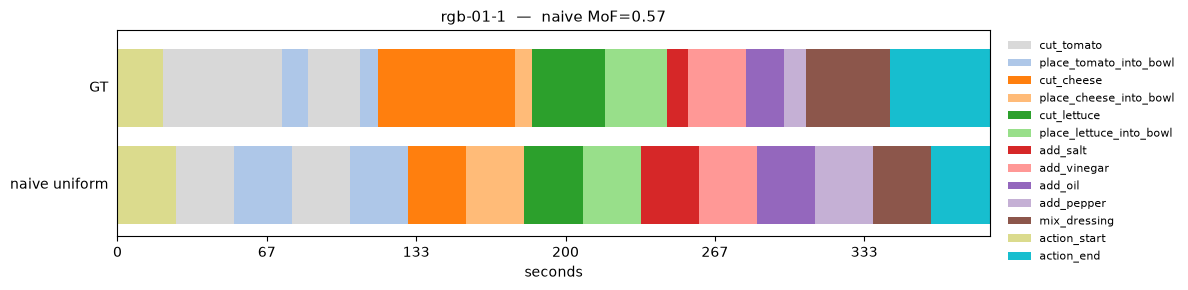

/Users/elizpayasli/Documents/GitHub/DELTA/src/delta/viz/timeline.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{t / fps:.0f}" for t in ticks])


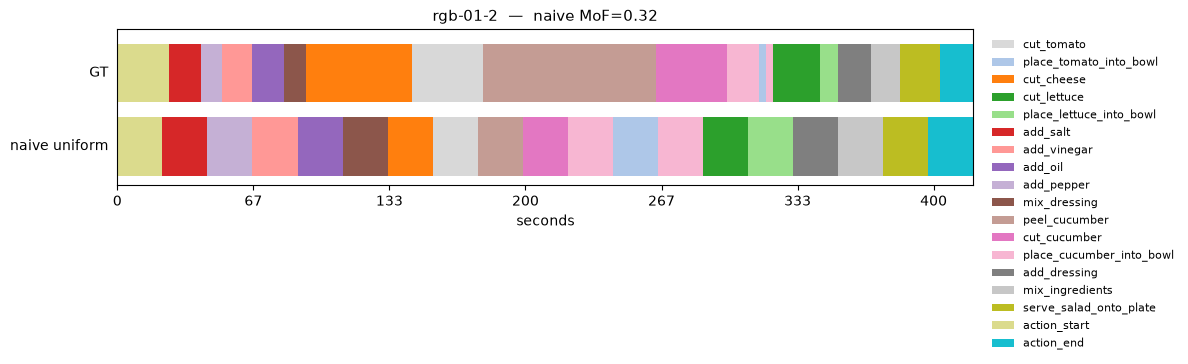

In [13]:
for vid in ds.split(1, "test")[:2]:
    rec = ds.record(vid)
    y_naive = stats.naive_uniform_labeling(rec.transcript, rec.num_label_frames)
    fig, _ = plot_segmentation(
        {"GT": rec.frame_labels, "naive uniform": y_naive},
        class_names=NAMES, fps=FPS,
        title=f"{vid}  —  naive MoF={segmentation_report(y_naive, rec.frame_labels)['MoF']:.2f}",
    )
    plt.show()

## 8. Breakfast comparison (deferred)

Needs the Breakfast bundle (`dinggd/breakfast`, ~larger). Once downloaded:
```python
bf = ActionSegDataset("breakfast", "data/breakfast")
pd.DataFrame([stats.dataset_summary(ds), stats.dataset_summary(bf)])
```
Expected contrast: BF ~6 segments/video vs 50S ~20; fewer, more separable steps
per video → the alignment "locks on" quickly on BF but not on 50S.

## Takeaways → `docs/50salads-notes.md`

1. **MoC over MoF** — frame counts are dominated by a few long actions; the
   interesting classes (`add_*`) are frame-rare but appear once per recipe.
2. **Duration is hard to learn from transcripts** — variable classes at CV ≈ 0.5–0.8.
3. **Order ≠ timing** — ~1.9 bits of next-action entropy; visual evidence must
   carry the alignment, and…
4. **…the visual evidence is weak** — fixed overhead camera, near-duplicate
   fine-grained classes, I3D consecutive-frame distance barely peaks at true
   boundaries (§5 ratio). This is the ATBA `v^b` candidate-generation problem.
5. **Long sequences** (~20 segments, ~11k frames) → one early boundary error
   propagates far.